In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('/content/data.csv')

In [ ]:
df.shape

(200, 4)

In [ ]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [ ]:
x = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
residual = y_test - y_pred

## Linear Relationship

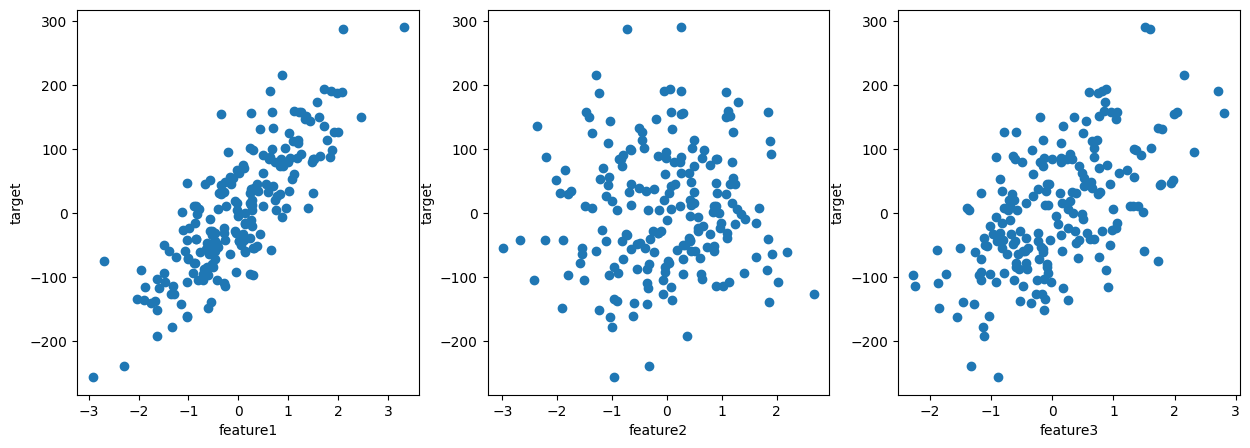

In [ ]:
fig, (ax1, ax2,ax3) = plt.subplots(ncols=3, figsize=(15, 5))

ax1.scatter(df['feature1'],df['target'])
ax1.set_xlabel('feature1')
ax1.set_ylabel('target')
ax2.scatter(df['feature2'],df['target'])
ax2.set_xlabel('feature2')
ax2.set_ylabel('target')
ax3.scatter(df['feature3'],df['target'])
ax3.set_xlabel('feature3')
ax3.set_ylabel('target')

plt.show()

## Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(x_train.shape[1]):
  vif.append(variance_inflation_factor(x_train,i))

In [ ]:
pd.DataFrame({'vif':vif},index = df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.003482,1.005274,1.006564


<Axes: >

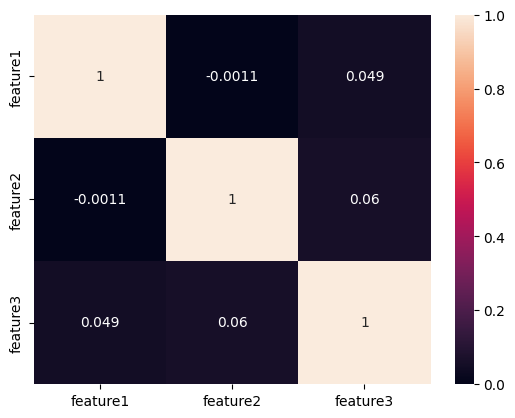

In [ ]:
# Another Technique

sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

## Normal Residual

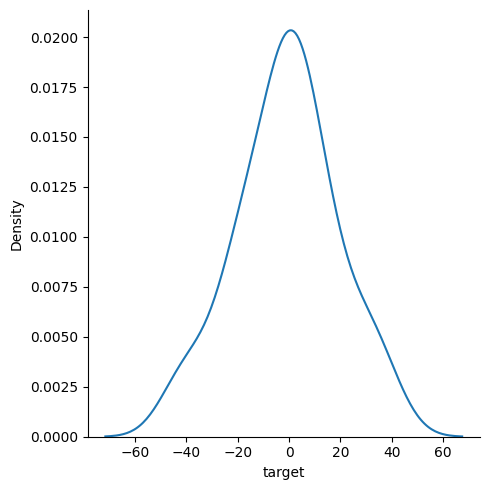

In [ ]:
sns.displot(residual,kind = 'kde')

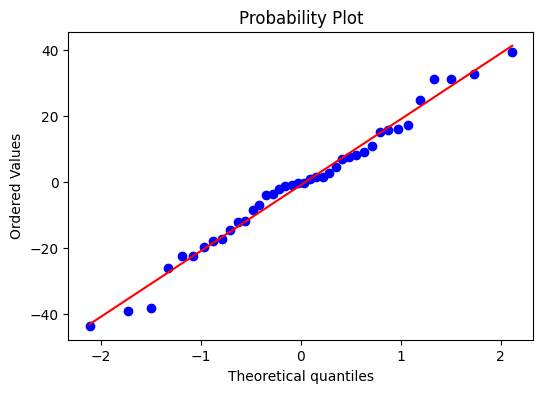

In [ ]:
# QQ plot

import scipy as sp

fig,ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual,plot=ax,fit = True)

plt.show()

## Homoscedasticity

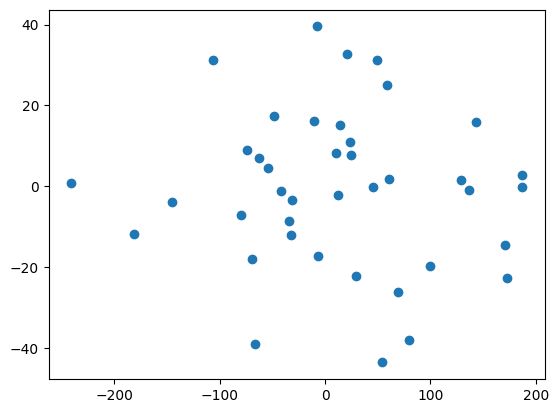

In [ ]:
plt.scatter(y_pred,residual)

## No Autocorrelations of Error

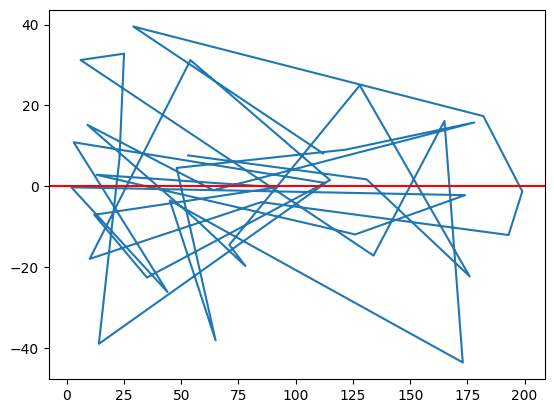

In [ ]:
plt.plot(residual)
plt.axhline(y=0, color='r')
plt.show()